In [1]:
#Import the libraries
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import matplotlib.dates as mdates

In [2]:
#Define output directory for the data
datadir = '/home/jovyan/SAMBBA_data/'

In [3]:
# Get all .nc files in the directory
file_paths = sorted(glob.glob(f'{datadir}/*.nc'))

file_paths  # List of all .nc file paths

['/home/jovyan/SAMBBA_data/core_faam_20120914_v004_r0_b731.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120915_v004_r0_b732.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120916_v004_r0_b733.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120919_v004_r0_b735.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120919_v004_r0_b736.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120920_v004_r0_b737.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120922_v004_r0_b738.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120923_v004_r0_b739.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120925_v004_r0_b740.nc',
 '/home/jovyan/SAMBBA_data/core_faam_20120929_v004_r0_b746.nc']

In [4]:
ds0 = xr.open_dataset(file_paths[0])
ds0

<xarray.Dataset> Size: 289MB
Dimensions:        (data_point: 26440, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                    sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/155)
    Time           (data_point) datetime64[ns] 212kB ...
    IAS_RVSM       (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAS_RVSM       (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG  (data_point, sps32) float32 3MB ...
    TAT_DI_R       (data_point, sps32) float32 3MB ...
    ...             ...
    TDEW_C_U       (data_point, sps01) float32 106kB ...
    TDEW_C_U_FLAG  (data_point, sps01) float32 106kB ...
    U_NOTURB       (data_point, sps01) float32 106kB ...
    U_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
    V_NOTURB       (data_point, sps01) float32 106kB ...
    V_NOTURB_FLAG  (data_point, sps01) float32 106kB ...
Attributes: (12/23)
    conventions:         CF-1.0
    title:               Data from b731 on 14-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20121015
    TimeInterval:        10:34:17-17:54:56
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120914_...
    quality:             Flight Number: b731\nFlight Date: 14/09/2012\nCheck ...

In [6]:
# Initialize empty lists to store latitudes, longitudes, flags, and additional variables
all_lats = []
all_lons = []
all_lats_flags = []
all_lons_flags = []
all_psap_lin = []
all_time = []
all_psap_log = []

# Loop through each file and extract latitude, longitude, and the additional variables
for file in file_paths:
    ds = xr.open_dataset(file)
    
    # Extract latitude, longitude, and flags
    lat = ds['LAT_GIN'].values
    lon = ds['LON_GIN'].values
    lat_flag = ds['LAT_GIN_FLAG'].values
    lon_flag = ds['LON_GIN_FLAG'].values
    
    # Extract PSAP_LIN, Time, and PSAP_LOG
    psap_lin = ds['PSAP_LIN'].values
    time = ds['Time'].values
    psap_log = ds['PSAP_LOG'].values
    
    # Append to the respective lists
    all_lats.append(lat)
    all_lons.append(lon)
    all_lats_flags.append(lat_flag)
    all_lons_flags.append(lon_flag)
    all_psap_lin.append(psap_lin)
    all_time.append(time)
    all_psap_log.append(psap_log)

# Concatenate all variables into single arrays
concatenated_lats = np.concatenate(all_lats, axis=0)
concatenated_lons = np.concatenate(all_lons, axis=0)
concatenated_lats_flag = np.concatenate(all_lats_flags, axis=0)
concatenated_lons_flag = np.concatenate(all_lons_flags, axis=0)
concatenated_psap_lin = np.concatenate(all_psap_lin, axis=0)
concatenated_time = np.concatenate(all_time, axis=0)
concatenated_psap_log = np.concatenate(all_psap_log, axis=0)

# You now have concatenated arrays for latitudes, longitudes, flags, PSAP_LIN, Time, and PSAP_LOG


In [7]:
concatenated_time

array(['2012-09-14T10:34:17.000000000', '2012-09-14T10:34:18.000000000',
       '2012-09-14T10:34:19.000000000', ...,
       '2012-09-29T16:44:39.000000000', '2012-09-29T16:44:40.000000000',
       '2012-09-29T16:44:41.000000000'], dtype='datetime64[ns]')

In [8]:
# Filter valid points (assuming 1 means valid, adjust this logic based on your flag meaning)
valid_points = (concatenated_lats_flag == 1) & (concatenated_lons_flag == 1)

# Select only valid latitude and longitude points using numpy boolean indexing
lat_valid = concatenated_lats[valid_points]
lon_valid = concatenated_lons[valid_points]

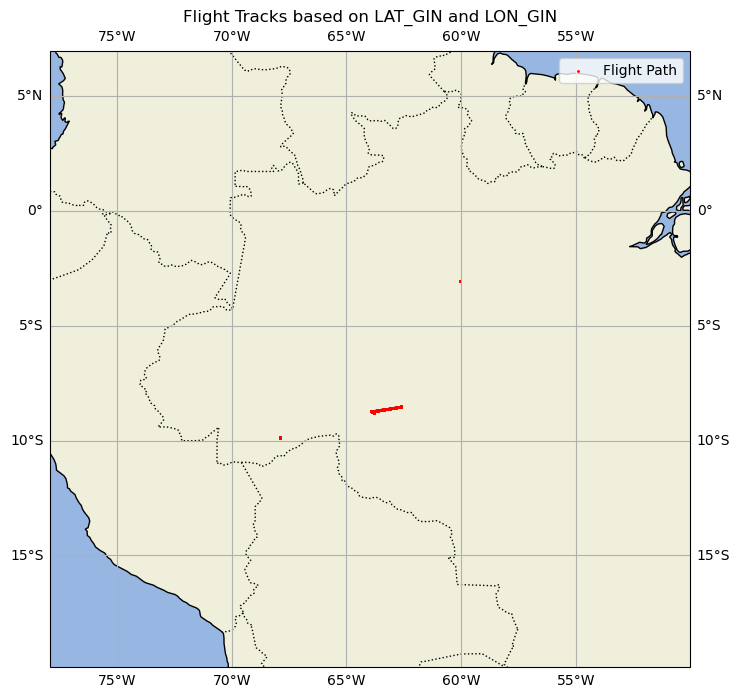

In [9]:
# Create a figure and axis with a Cartopy map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent (adjust based on the region you're plotting)
ax.set_extent([lon_valid.min()-10, lon_valid.max()+10, lat_valid.min()-10, lat_valid.max()+10], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)

# Plot the latitude and longitude points
ax.scatter(lon_valid, lat_valid, color='red', s=1, transform=ccrs.PlateCarree(), label="Flight Path")

# Optionally add a title and legend
plt.title('Flight Tracks based on LAT_GIN and LON_GIN')
plt.legend()

# Show the plot
plt.show()

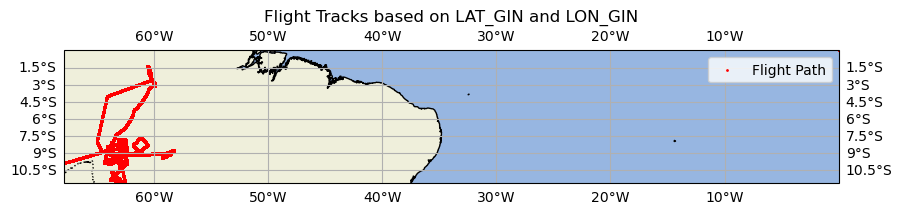

In [10]:
# Create a figure and axis with a Cartopy map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent (adjust based on the region you're plotting)
ax.set_extent([concatenated_lons.min(), concatenated_lons.max(), concatenated_lats.min(), concatenated_lats.max()], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)

# Plot the latitude and longitude points
ax.scatter(concatenated_lons, concatenated_lats, color='red', s=1, transform=ccrs.PlateCarree(), label="Flight Path")

# Optionally add a title and legend
plt.title('Flight Tracks based on LAT_GIN and LON_GIN')
plt.legend(loc='upper right')

# Show the plot
plt.show()

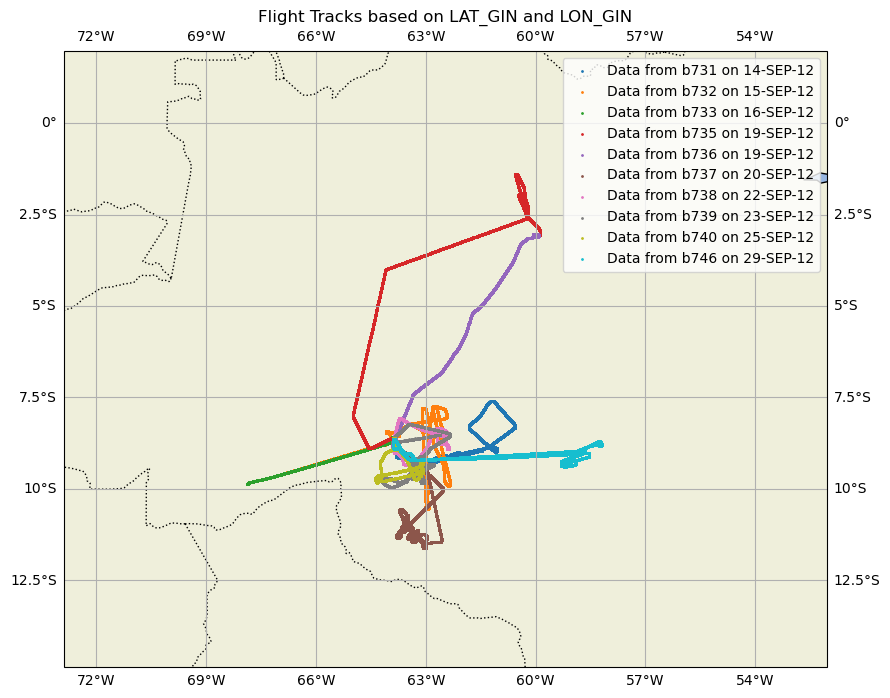

In [11]:
# Create a figure and axis with a Cartopy map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent (adjust based on the region you're plotting)
ax.set_extent([lon_valid.min()-5, lon_valid.max()+8, lat_valid.min()-5, lat_valid.max()+5], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)

# Loop through each dataset to plot flight tracks
for file in (file_paths):
    ds = xr.open_dataset(file)
    
    # Extract latitude and longitude for the current dataset
    lat = ds['LAT_GIN'].values.flatten()
    lon = ds['LON_GIN'].values.flatten()
    
    # Get the title for the current dataset to use as a label
    track_title = ds.attrs.get('title', 'Unknown Track')

    # Plot the latitude and longitude points for the current flight track
    ax.scatter(lon, lat, s=1, transform=ccrs.PlateCarree(), label=track_title)

# Optionally add a title and legend
plt.title('Flight Tracks based on LAT_GIN and LON_GIN')
plt.legend(loc='upper right')

# Show the plot
plt.show()


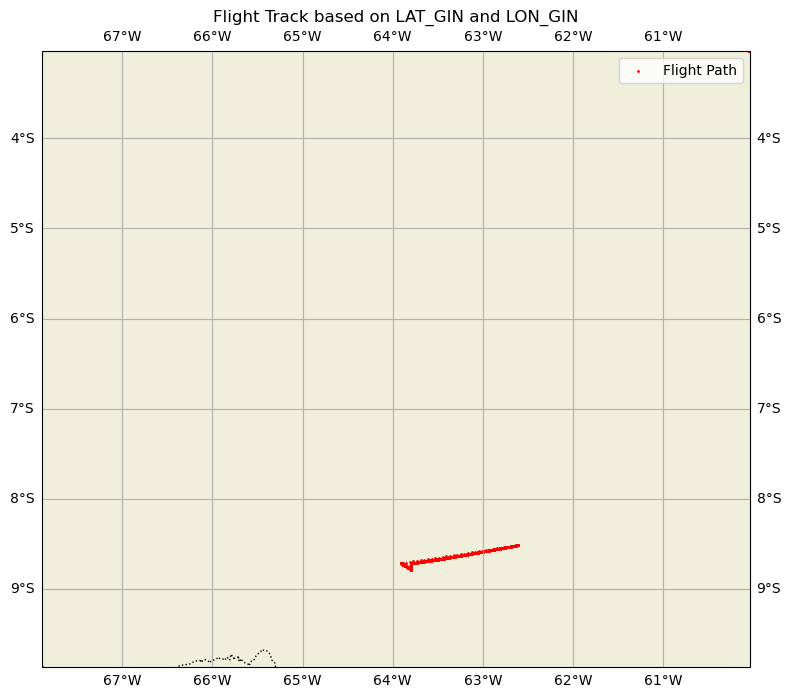

In [12]:
# Create a figure and axis with a Cartopy map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent (adjust based on the region you're plotting)
ax.set_extent([lon_valid.min(), lon_valid.max(), lat_valid.min(), lat_valid.max()], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.gridlines(draw_labels=True)

# Plot the latitude and longitude points
ax.scatter(lon_valid, lat_valid, color='red', s=1, transform=ccrs.PlateCarree(), label="Flight Path")

# Optionally add a title and legend
plt.title('Flight Track based on LAT_GIN and LON_GIN')
plt.legend()

# Show the plot
plt.show()

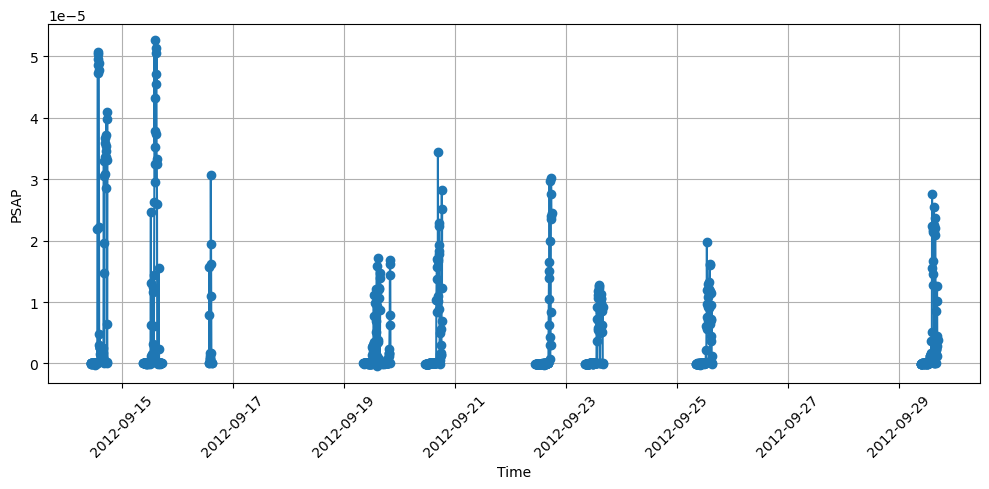

In [13]:
# Step 1: Extract the PSAP_LOG and time data
PSAP = concatenated_psap_lin.flatten()  # Flatten the PSAP_LOG array
time_values = pd.to_datetime(concatenated_time.flatten())  # Flatten the time values and convert to pandas datetime

# Step 2: Create a pandas DataFrame for easier resampling
df = pd.DataFrame({
    'PSAP': PSAP,
    'Time': time_values
})

# Step 3: Set 'Time' as the index
df.set_index('Time', inplace=True)

# Step 4: Resample the data to 5-minute intervals (adjust '5T' to '1T' or '10T' for 1 or 10 minutes)
resampled_df = df.resample('5min').mean()  # Use '5T' for 5-minute intervals. Can change to '1T' or '10T'

# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(resampled_df.index, resampled_df['PSAP'], marker='o')

plt.xlabel('Time')
plt.ylabel('PSAP')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()

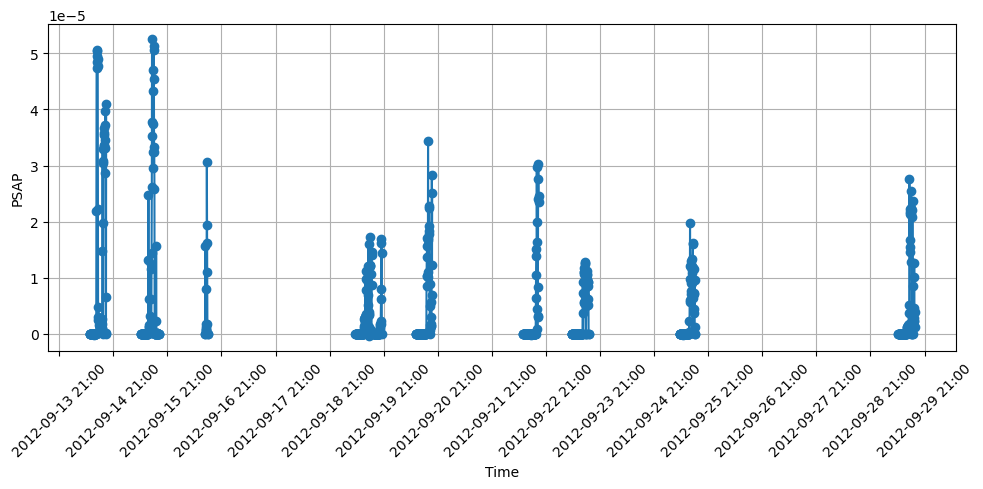

In [14]:
# Step 1: Extract the PSAP_LOG and time data
PSAP = concatenated_psap_lin.flatten()  # Flatten the PSAP_LOG array
time_values = pd.to_datetime(concatenated_time.flatten())  # Flatten the time values and convert to pandas datetime

# Step 2: Create a pandas DataFrame for easier resampling
df = pd.DataFrame({
    'PSAP': PSAP,
    'Time': time_values
})

# Step 3: Set 'Time' as the index
df.set_index('Time', inplace=True)

# Step 4: Resample the data to 5-minute intervals
resampled_df = df.resample('5min').mean()  # '5min' for 5-minute intervals

# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(resampled_df.index, resampled_df['PSAP'], marker='o')

# Step 6: Set time axis ticks to show every 12 hours
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=24))  # Set major ticks every 12 hours
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))  # Format the tick labels

plt.xlabel('Time')
plt.ylabel('PSAP')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()


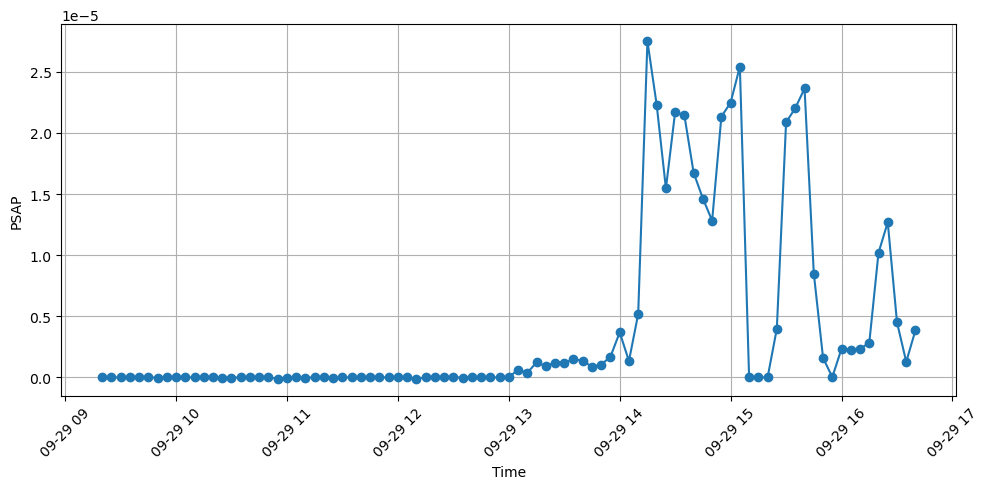

In [15]:
# Step 1: Extract the PSAP_LOG and time data
PSAP = ds['PSAP_LIN'].values.flatten()  # Flatten the PSAP_LOG array
time_values = pd.to_datetime(ds['Time'].values.flatten())  # Flatten the time values and convert to pandas datetime

# Step 2: Create a pandas DataFrame for easier resampling
df = pd.DataFrame({
    'PSAP': PSAP,
    'Time': time_values
})

# Step 3: Set 'Time' as the index
df.set_index('Time', inplace=True)

# Step 4: Resample the data to 5-minute intervals (adjust '5T' to '1T' or '10T' for 1 or 10 minutes)
resampled_df = df.resample('5min').mean()  # Use '5T' for 5-minute intervals. Can change to '1T' or '10T'

# Step 5: Plot the resampled PSAP_LOG values
plt.figure(figsize=(10, 5))

# Plot resampled PSAP_LOG values
plt.plot(resampled_df.index, resampled_df['PSAP'], marker='o')

plt.xlabel('Time')
plt.ylabel('PSAP')
plt.xticks(rotation=45)
plt.grid()

# Tight layout for better plot formatting
plt.tight_layout()

# Show the plot
plt.show()